In [15]:
!pip install yfinance pandas numpy python-dotenv

import yfinance as yf
import pandas as pd
import numpy as np

In [16]:
#Check of versions of libraries
import yfinance, pandas, numpy, matplotlib

print("yfinance==", yfinance.__version__)
print("pandas==", pandas.__version__)
print("numpy==", numpy.__version__)
print("matplotlib==", matplotlib.__version__)

yfinance== 1.4.1
pandas== 2.3.3
numpy== 2.3.5
matplotlib== 3.10.6


In [17]:
#CORE DATA
tickers = ["EOAN.DE", "IBE.MC", "TTE.PA", "BP.L", "ENGI.PA", "EQNR.OL"]

data = yf.download(tickers, start="2020-01-01", end="2026-01-01")
prices = data["Close"]
volume = data["Volume"]
print(prices.head())
print(volume.head())

#Quick check of NA
print(prices.isna().sum())

#We carry the last price to avoid NA bc of stock market closure
prices_clean = prices.ffill().dropna()
volume_clean = volume.ffill().dropna()
print(prices_clean.isna().sum())
print(volume_clean.isna().sum())

#Log returns
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()
print(log_returns.head())

#Risk profile
print(log_returns.describe())

#Annual data
annual_return = log_returns.mean() * 252
annual_volatility = log_returns.std() * np.sqrt(252)

print("Annual Return:")
print(annual_return)
print("\nAnnual volatility:")
print(annual_volatility)

[*********************100%***********************]  6 of 6 completed

Ticker            BP.L   ENGI.PA   EOAN.DE     EQNR.OL    IBE.MC     TTE.PA
Date                                                                       
2020-01-02  479.180206  9.530099  7.154588  123.809593  7.043620  32.773640
2020-01-03  492.334381  9.526856  7.088219  125.896851  7.011535  33.145355
2020-01-06  502.349457  9.536583  7.060627  128.714630  6.976391  33.625347
2020-01-07  497.067810  9.656561  7.009917  127.323143  6.840409  33.405350
2020-01-08  492.583466  9.643590  7.033033  127.740601  6.863327  33.492020
Ticker            BP.L    ENGI.PA    EOAN.DE    EQNR.OL      IBE.MC     TTE.PA
Date                                                                          
2020-01-02  25049010.0  4764834.0  5821140.0  2291540.0  11454601.0  4326276.0
2020-01-03  42354025.0  3524034.0  6854797.0  3386147.0  12836478.0  4960724.0
2020-01-06  47220192.0  3303239.0  4819381.0  3819223.0   9389610.0  7596924.0
2020-01-07  46243068.0  7040954.0  8756103.0  2878558.0  24582731.0  5380

In [18]:
#We want to have a benchmark (reference)

benchmark = yf.download("OIL.PA", start="2020-01-01", end="2026-01-01")["Close"]
benchmark_clean = benchmark.ffill().dropna()
print(prices_clean.head())

[*********************100%***********************]  1 of 1 completed

Ticker            BP.L   ENGI.PA   EOAN.DE     EQNR.OL    IBE.MC     TTE.PA
Date                                                                       
2020-01-02  479.180206  9.530099  7.154588  123.809593  7.043620  32.773640
2020-01-03  492.334381  9.526856  7.088219  125.896851  7.011535  33.145355
2020-01-06  502.349457  9.536583  7.060627  128.714630  6.976391  33.625347
2020-01-07  497.067810  9.656561  7.009917  127.323143  6.840409  33.405350
2020-01-08  492.583466  9.643590  7.033033  127.740601  6.863327  33.492020


In [19]:
#VaR 
#(what's the worst I can lose in a bad day?) If 95%, 95% of days wont surpass this threshold, but 5% will
VaR_95 = log_returns.quantile(0.05)
print(VaR_95)

#Sharpe ratio (Sharpe = Return / volatility)
#To management a portfolio, we have to see how much return do we get per unit of risk. Higher = better
sharpe = annual_return / annual_volatility
print(sharpe)

log_returns.to_csv("log_returns.csv")

#Correlation
correlation = log_returns.corr()
cov_matrix = log_returns.cov() * 252
print(cov_matrix)


Ticker
BP.L      -0.032217
ENGI.PA   -0.021125
EOAN.DE   -0.022385
EQNR.OL   -0.031412
IBE.MC    -0.019160
TTE.PA    -0.027660
Name: 0.05, dtype: float64
Ticker
BP.L      -0.047729
ENGI.PA    0.520876
EOAN.DE    0.570168
EQNR.OL    0.312726
IBE.MC     0.717602
TTE.PA     0.270794
dtype: float64
Ticker       BP.L   ENGI.PA   EOAN.DE   EQNR.OL    IBE.MC    TTE.PA
Ticker                                                             
BP.L     0.122403  0.033422  0.015823  0.073421  0.019244  0.089596
ENGI.PA  0.033422  0.064086  0.031561  0.019565  0.031163  0.032846
EOAN.DE  0.015823  0.031561  0.050468  0.010354  0.027251  0.018191
EQNR.OL  0.073421  0.019565  0.010354  0.107209  0.012677  0.062603
IBE.MC   0.019244  0.031163  0.027251  0.012677  0.046931  0.020116
TTE.PA   0.089596  0.032846  0.018191  0.062603  0.020116  0.093284


In [20]:
#MONTE-CARLO PORTFOLIO SIMULATION 1 - Data
#Number of random portfolios + weights
n_portfolios = 5000
n_assets = len(tickers)

#Generate random weights that sum  to 1
weights = np.random.random((n_portfolios, n_assets))
weights = weights / weights.sum(axis=1)[:, None]

weights = np.clip(weights, 0.05, 0.40)
weights = weights / weights.sum(axis=1)[:, None]
    #We clip the values outside 0f >0.05 and <0-40 to make realistic weights

#Expected annual return + covariance
mu = annual_return.values
cov = cov_matrix.values

#Portfolio returns + volatility
#Portfolio return = weighted average of individual returns
#Portfolio volatility = sqrt(w^T * Cov * w)
#einsum is a fast way to compute this for all 5'000 portfolios at once
port_return = weights.dot(mu)
port_vol = np.sqrt(np.einsum('ij,jk,ik->i', weights, cov, weights))
 

#Sharpe ratio (risk-free=0)
port_sharpe = port_return / port_vol

#Results
results = pd.DataFrame({
    "Return": port_return,
    "Volatility": port_vol,
    "Sharpe": port_sharpe
        })

#Add weights to the Data Frame
weights_df = pd.DataFrame(weights, columns=tickers)
full_results = pd.concat([results, weights_df], axis=1)

full_results.head()

,Return,Volatility,Sharpe,EOAN.DE,IBE.MC,TTE.PA,BP.L,ENGI.PA,EQNR.OL
0,0.112493,0.198537,0.566610,0.047990,0.086667,0.240493,0.358923,0.169289,0.096638
1,0.093760,0.208592,0.449492,0.188932,0.151621,0.120197,0.160463,0.189239,0.189548
2,0.104619,0.190547,0.549048,0.163337,0.245705,0.352635,0.065226,0.120742,0.052355
3,0.085890,0.210514,0.407999,0.237603,0.210566,0.236167,0.107097,0.049832,0.158734
4,0.105133,0.200859,0.523417,0.091609,0.269377,0.213823,0.067952,0.099652,0.257587


Max Sharpe Portfolio:
Return        0.125408
Volatility    0.178812
Sharpe        0.701339
EOAN.DE       0.045694
IBE.MC        0.045694
TTE.PA        0.335124
BP.L          0.162237
ENGI.PA       0.365556
EQNR.OL       0.045694
Name: 4510, dtype: float64


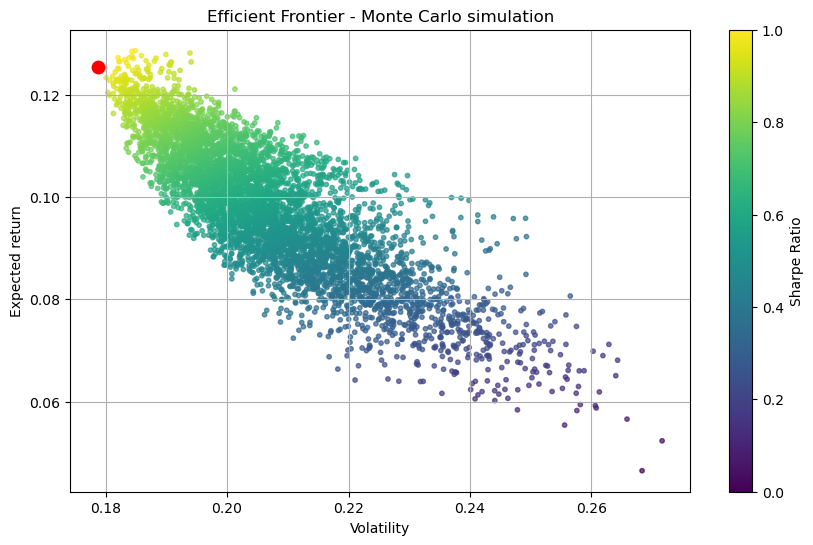

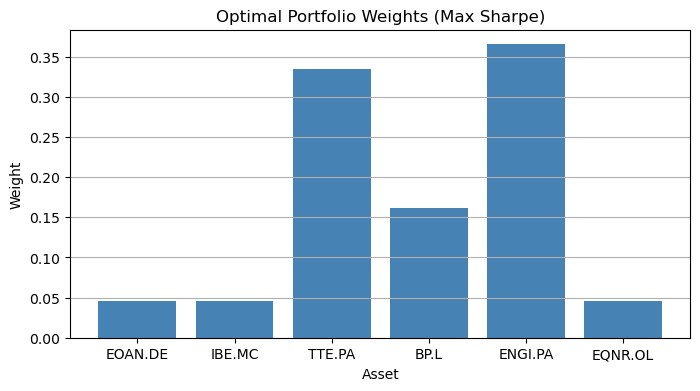

In [21]:
#MONTE-CARLO PORTFOLIO SIMULATION 2 - Efficient frontier

#Find the portfolio composition with the highest Sharpe ratio
max_sharpe_idx = full_results["Sharpe"].idxmax()

#Extract the full row (return, vol, sharpe, weights)
max_sharpe_port = full_results.loc[max_sharpe_idx]

print("Max Sharpe Portfolio:")
print(max_sharpe_port)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

#Scatter plot of all random portfolios
plt.scatter(
    full_results["Volatility"],
    full_results["Return"],
    c=full_results["Sharpe"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.scatter(
    max_sharpe_port["Volatility"],
    max_sharpe_port["Return"],
    color="red",
    s=80,
    label="Max Sharpe")
        
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected return")
plt.title("Efficient Frontier - Monte Carlo simulation")
plt.grid(True)
plt.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

#The upper left grid is the efficient frontier, where the risk is lowest and reward is highest

# Optimal portfolio weights as a table
weights_only = max_sharpe_port[tickers]

plt.figure(figsize=(8, 4))
plt.bar(weights_only.index, weights_only.values, color="steelblue")
plt.title("Optimal Portfolio Weights (Max Sharpe)")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.savefig("optimal_weights.png", dpi=300, bbox_inches="tight")
plt.show()

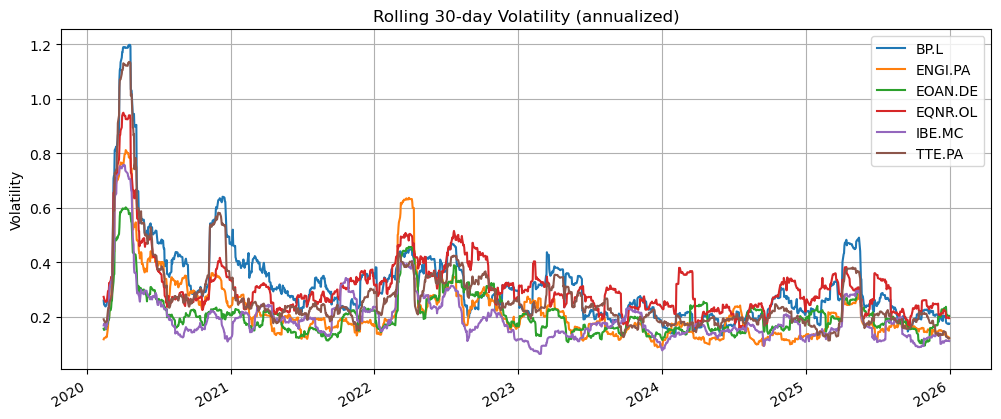

Ticker       Date      BP.L   ENGI.PA   EOAN.DE   EQNR.OL    IBE.MC    TTE.PA
28     2020-02-12       NaN       NaN       NaN       NaN       NaN       NaN
29     2020-02-13  0.260076  0.117801  0.156863  0.273716  0.168879  0.191426
30     2020-02-14  0.245894  0.121934  0.152050  0.267102  0.175296  0.186810


In [22]:
#ROLLING VOLATILITY (30-day window)
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

rolling_vol.plot(figsize=(12, 5), title = "Rolling 30-day Volatility (annualized)")
plt.xlabel("")
plt.ylabel("Volatility")
plt.legend(loc="upper right")
plt.grid(True)
plt.savefig("rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

print(rolling_vol.reset_index().iloc[28:31])  # what date is at row 29 (0-indexed 28)?

In [23]:
#SQL

#Data transformation into a SQL-friendly format

prices_long = prices_clean.reset_index().melt(
    id_vars="Date",
    var_name="ticker",
    value_name="close"
)
volume_long = volume_clean.reset_index().melt(
    id_vars="Date",
    var_name="ticker",
    value_name="volume"
)
benchmark_long = benchmark_clean.reset_index().melt(
    id_vars="Date",
    var_name="ticker",
    value_name="close"
)
#Reset bc we needs date as a regular colum, not as an index

print(benchmark_long["ticker"].unique())

['OIL.PA']


In [24]:
#We create a dataframe with prices_long + volume_long
portfolio_long = prices_long.merge(
    volume_long,
    on = ["Date", "ticker"]
)
print(portfolio_long.head())

        Date ticker       close      volume
0 2020-01-02   BP.L  479.180206  25049010.0
1 2020-01-03   BP.L  492.334381  42354025.0
2 2020-01-06   BP.L  502.349457  47220192.0
3 2020-01-07   BP.L  497.067810  46243068.0
4 2020-01-08   BP.L  492.583466  37974090.0


In [27]:
#We export the data to SQL with hidden password
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text

load_dotenv()
DB_URI = os.environ["SUPABASE_DB_URI"]
engine = create_engine(DB_URI)

#Table instrument in SQL
instruments = pd.DataFrame({
    "ticker": tickers + ["OIL.PA"],
    "is_benchmark": [False]*len(tickers) + [True]
})

#We use "engine" to connect to SQL
with engine.begin() as conn:
    for _, row in instruments.iterrows():
        conn.execute(text("""
            INSERT INTO instruments (ticker, is_benchmark)
            VALUES (:ticker, :is_benchmark)
            ON CONFLICT (ticker) DO NOTHING
        """), {"ticker": row["ticker"], "is_benchmark": row["is_benchmark"]})

In [30]:
#Load prices table into Supabase (robust)
portfolio_long_renamed = portfolio_long.rename(columns={"Date": "trade_date"})
benchmark_long_renamed = benchmark_long.rename(columns={"Date": "trade_date"})
benchmark_long_renamed["volume"] = None

all_prices = pd.concat([portfolio_long_renamed, benchmark_long_renamed])

with engine.begin() as conn:
    for _, row in all_prices.iterrows():
        conn.execute(text("""
            INSERT INTO prices (ticker, trade_date, close, volume)
            VALUES (:ticker, :trade_date, :close, :volume)
            ON CONFLICT (ticker, trade_date) DO NOTHING
        """), {
            "ticker": row["ticker"],
            "trade_date": row["trade_date"],
            "close": row["close"],
            "volume": None if pd.isna(row["volume"]) else row["volume"]
        })

C:\Users\pc\AppData\Local\Temp\ipykernel_444\1399068866.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prices = pd.concat([portfolio_long_renamed, benchmark_long_renamed])


In [39]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM prices"))
    print(result.fetchone())

(10331,)
